In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Base completa


In [14]:
excel_file_path = '/content/base_normalizada_completa.xlsx'

# Diccionario para almacenar los dataframes de cada hoja
dfs = {}

# Columnas a seleccionar para cada hoja (si no se especifica, se toman todas)
sheet_columns = {
    'CaracteristicasGenerales': None, # Todas las columnas
    'Fisicas': None, # Todas las columnas
    'SignosVitales': None, # Todas las columnas
    'Bioquimicos': ['Paciente_ID', 'glu', 'HIPOGLUCEMIANTE'],
    'Circunferencias': None, # Todas las columnas
    'PerfilLipidico': ['Paciente_ID', 'chol', 'tg', 'hdlc', 'ldlc'],
    'Antihipertensivos': ['Paciente_ID', 'aHTNdrugs', 'ACEi', 'ARA2', 'CCB', 'Diuretic', 'BB', 'ANTIHIPERTENSIVO'],
    'Diagnosticos': ['Paciente_ID', 'PADECIMIENTO_DIABETES', 'PADECIMIENTO_HIPERTENSION'],
    'HabitosAlimentarios': None, # Todas las columnas
    'AdherenciaMedicacion': ['Paciente_ID', 'GRADO_DE_ADHERENCIA_MORISKY_GREEN', 'SABE_PARA_QUE_TOMA_SUS_MEDICAMENTOS'],
    'DeteccionYControl': ['Paciente_ID', 'DETECCION_Y_CONTROL_HIPERTENSION'],
    'ActividadReciente': ['Paciente_ID',
                         'EN_LA_ULTIMA_SEMANA_CUANTOS_DIAS_REALIZO_ACTIVIDADES_SEDENTARIAS',
                         'EN_LA_ULTIMA_SEMANA_CUANTOS_DIAS_REALIZO_CAMINATAS',
                         'EN_LA_ULTIMA_SEMANA_CUANTAS_HORAS_POR_DIA_HA_CAMINADO']
}

# Cargar cada hoja en un dataframe
for sheet_name, cols_to_use in sheet_columns.items():
    print(f"Cargando hoja: {sheet_name}")
    if cols_to_use is None:
        dfs[sheet_name] = pd.read_excel(excel_file_path, sheet_name=sheet_name)
    else:
        dfs[sheet_name] = pd.read_excel(excel_file_path, sheet_name=sheet_name, usecols=cols_to_use)

# Inicializar el dataframe maestro con CaracteristicasGenerales
df_master = dfs['CaracteristicasGenerales'].copy()
print(f"\nDataFrame maestro inicializado con '{len(df_master)}' filas de 'CaracteristicasGenerales'.")

# Unir las demás hojas al dataframe maestro
for sheet_name, current_df in dfs.items():
    if sheet_name != 'CaracteristicasGenerales':
        print(f"Uniendo hoja: {sheet_name} (shape: {current_df.shape}) a df_master (shape: {df_master.shape})")
        df_master = pd.merge(df_master, current_df, on='Paciente_ID', how='left')
        print(f"df_master shape después de unir {sheet_name}: {df_master.shape}")

print("\n--- Procesamiento completado ---")
# 1. Mostrar el shape del dataframe maestro.
print(f"Shape final del dataframe maestro: {df_master.shape}")

# 2. Muestra df.columns.tolist()
print("\nColumnas finales del dataframe maestro:")
display(df_master.columns.tolist())

# 3. Muestra df.isnull().sum() para ver missingness.
print("\nConteo de valores nulos por columna en el dataframe maestro:")
display(df_master.isnull().sum())

Cargando hoja: CaracteristicasGenerales
Cargando hoja: Fisicas
Cargando hoja: SignosVitales
Cargando hoja: Bioquimicos
Cargando hoja: Circunferencias
Cargando hoja: PerfilLipidico
Cargando hoja: Antihipertensivos
Cargando hoja: Diagnosticos
Cargando hoja: HabitosAlimentarios
Cargando hoja: AdherenciaMedicacion
Cargando hoja: DeteccionYControl
Cargando hoja: ActividadReciente

DataFrame maestro inicializado con '966' filas de 'CaracteristicasGenerales'.
Uniendo hoja: Fisicas (shape: (966, 4)) a df_master (shape: (966, 3))
df_master shape después de unir Fisicas: (966, 6)
Uniendo hoja: SignosVitales (shape: (966, 7)) a df_master (shape: (966, 6))
df_master shape después de unir SignosVitales: (966, 12)
Uniendo hoja: Bioquimicos (shape: (966, 3)) a df_master (shape: (966, 12))
df_master shape después de unir Bioquimicos: (966, 14)
Uniendo hoja: Circunferencias (shape: (966, 7)) a df_master (shape: (966, 14))
df_master shape después de unir Circunferencias: (966, 20)
Uniendo hoja: PerfilLi

['Paciente_ID',
 'Sx',
 'agey',
 'weightKg',
 'heightm',
 'IMC_KG_M2',
 'SBP',
 'DBP',
 'pulse',
 'Pulso',
 'PRESION_SISTOLICA',
 'PRESION_DIASTOLICA',
 'glu',
 'HIPOGLUCEMIANTE',
 'CINTURA_CM_1',
 'CINTURA_CM_2',
 'CINTURA_CM_3',
 'CADERA_CM_1',
 'CADERA_CM_2',
 'CADERA_CM_3',
 'chol',
 'tg',
 'hdlc',
 'ldlc',
 'aHTNdrugs',
 'ACEi',
 'ARA2',
 'CCB',
 'Diuretic',
 'BB',
 'ANTIHIPERTENSIVO',
 'PADECIMIENTO_DIABETES',
 'PADECIMIENTO_HIPERTENSION',
 'CUANTAS_CUCHARADAS_TOTALES_DE_AZUCAR_AGREGA_A_SUS_COMIDAS_EN_UN_DIA',
 'AGREGA_SAL_A_SUS_ALIMENTOS_ANTES_DE_PROBARLOS',
 'GRADO_DE_ADHERENCIA_MORISKY_GREEN',
 'SABE_PARA_QUE_TOMA_SUS_MEDICAMENTOS',
 'DETECCION_Y_CONTROL_HIPERTENSION',
 'EN_LA_ULTIMA_SEMANA_CUANTOS_DIAS_REALIZO_ACTIVIDADES_SEDENTARIAS',
 'EN_LA_ULTIMA_SEMANA_CUANTOS_DIAS_REALIZO_CAMINATAS',
 'EN_LA_ULTIMA_SEMANA_CUANTAS_HORAS_POR_DIA_HA_CAMINADO']


Conteo de valores nulos por columna en el dataframe maestro:


,0
Paciente_ID,0
Sx,6
agey,6
weightKg,8
heightm,8
IMC_KG_M2,133
SBP,10
DBP,10
pulse,11
Pulso,503


### Limpieza estructural del dataframe maestro

In [15]:
# Make a copy to work on, ensuring we don't modify the original `df_master` if running the cell multiple times
df = df_master.copy()

print("--- Iniciando limpieza estructural ---")

# 1. ELIMINAR columnas duplicadas
columns_to_drop_duplicates = ['PRESION_SISTOLICA', 'PRESION_DIASTOLICA', 'Pulso', 'IMC_KG_M2']
df = df.drop(columns=[col for col in columns_to_drop_duplicates if col in df.columns], errors='ignore')
print(f"Columnas duplicadas eliminadas: {', '.join([col for col in columns_to_drop_duplicates if col not in df.columns])}")

# 2. CORREGIR heightm
# Valores >= 3 están en centímetros, dividir entre 100
df.loc[df['heightm'] >= 3, 'heightm'] = df.loc[df['heightm'] >= 3, 'heightm'] / 100
print(f"'heightm' corregida. Media verificada: {df['heightm'].mean():.2f}")

# 3. CALCULAR IMC limpio
df['IMC'] = df['weightKg'] / (df['heightm'] ** 2)
print("'IMC' recalculada.")

# 4. IMPUTAR medicamentos binarios con 0 y recalcular n_medicamentos
medication_columns_binary = ['ACEi', 'ARA2', 'CCB', 'Diuretic', 'BB']
for col in medication_columns_binary:
    df[col] = df[col].fillna(0).astype(int)
print("NaN en columnas de medicamentos binarios rellenados con 0.")
df['n_medicamentos'] = df[medication_columns_binary].sum(axis=1)
# Update aHTNdrugs as per previous notebook logic
df['aHTNdrugs'] = df['n_medicamentos']
print("'n_medicamentos' recalculada y 'aHTNdrugs' actualizada.")

# 5. ESTANDARIZAR columnas categóricas de Sí/No a binario 0/1
si_no_mapping = {
    'SI': 1, 'Si': 1, 'SÍ': 1,
    'NO': 0, 'No': 0
}

columns_to_convert_to_binary = [
    'HIPOGLUCEMIANTE',
    'ANTIHIPERTENSIVO',
    'PADECIMIENTO_DIABETES',
    'PADECIMIENTO_HIPERTENSION',
    'AGREGA_SAL_A_SUS_ALIMENTOS_ANTES_DE_PROBARLOS',
    'SABE_PARA_QUE_TOMA_SUS_MEDICAMENTOS',
    'DETECCION_Y_CONTROL_HIPERTENSION'
]

for col in columns_to_convert_to_binary:
    if col in df.columns:
        df[col] = df[col].map(si_no_mapping).astype(float)
        # Convert NaN to float where needed, as map returns NaN for unmapped values
    else:
        print(f"Advertencia: Columna '{col}' no encontrada para conversión binaria.")
print("Columnas categóricas 'Sí/No' estandarizadas a binario.")

print("\n--- Limpieza estructural completada ---")

# 6. Mostrar el shape del dataframe
print(f"Shape final del dataframe: {df.shape}")

# Mostrar df.dtypes
print("\nTipos de datos del dataframe:")
display(df.dtypes)

# Mostrar df.isnull().sum() para ver missingness.
print("\nConteo de valores nulos por columna:")
display(df.isnull().sum())

--- Iniciando limpieza estructural ---
Columnas duplicadas eliminadas: PRESION_SISTOLICA, PRESION_DIASTOLICA, Pulso, IMC_KG_M2
'heightm' corregida. Media verificada: 1.58
'IMC' recalculada.
NaN en columnas de medicamentos binarios rellenados con 0.
'n_medicamentos' recalculada y 'aHTNdrugs' actualizada.
Columnas categóricas 'Sí/No' estandarizadas a binario.

--- Limpieza estructural completada ---
Shape final del dataframe: (966, 39)

Tipos de datos del dataframe:


,0
Paciente_ID,object
Sx,float64
agey,float64
weightKg,float64
heightm,float64
SBP,float64
DBP,float64
pulse,float64
glu,float64
HIPOGLUCEMIANTE,float64



Conteo de valores nulos por columna:


,0
Paciente_ID,0
Sx,6
agey,6
weightKg,8
heightm,8
SBP,10
DBP,10
pulse,11
glu,37
HIPOGLUCEMIANTE,6


### Preparación del DataFrame para análisis

In [16]:
# 1. PROMEDIAR circunferencias
circumference_cols_cintura = ['CINTURA_CM_1', 'CINTURA_CM_2', 'CINTURA_CM_3']
df['CINTURA_CM'] = df[circumference_cols_cintura].mean(axis=1)

circumference_cols_cadera = ['CADERA_CM_1', 'CADERA_CM_2', 'CADERA_CM_3']
df['CADERA_CM'] = df[circumference_cols_cadera].mean(axis=1)

df['RATIO_CINTURA_CADERA'] = df['CINTURA_CM'] / df['CADERA_CM']

df = df.drop(columns=circumference_cols_cintura + circumference_cols_cadera, errors='ignore')

print("Circunferencias promediadas y columnas originales eliminadas.")
display(df[['CINTURA_CM', 'CADERA_CM', 'RATIO_CINTURA_CADERA']].head())

Circunferencias promediadas y columnas originales eliminadas.


,CINTURA_CM,CADERA_CM,RATIO_CINTURA_CADERA
0,95.100000,98.033333,0.970078
1,106.333333,116.600000,0.911950
2,91.066667,107.266667,0.848975
3,93.266667,87.300000,1.068347
4,103.866667,115.333333,0.900578


In [17]:
# 2. CODIFICAR actividad reciente con midpoints numéricos

# Mapeo para DIAS_SEDENTARIOS y DIAS_CAMINATAS
days_frequency_mapping = {
    'NUNCA': 0,
    'de 1-2': 1.5,
    'de 3-4': 3.5,
    'de 5-7': 6,
    'de NO APLICA': pd.NA, # Mantiene NaN
    'NA': pd.NA # Mantiene NaN
}

df['DIAS_SEDENTARIOS'] = pd.to_numeric(df['EN_LA_ULTIMA_SEMANA_CUANTOS_DIAS_REALIZO_ACTIVIDADES_SEDENTARIAS'].map(days_frequency_mapping), errors='coerce')
df['DIAS_CAMINATAS'] = pd.to_numeric(df['EN_LA_ULTIMA_SEMANA_CUANTOS_DIAS_REALIZO_CAMINATAS'].map(days_frequency_mapping), errors='coerce')

# Mapeo para HORAS_CAMINANDO
hours_walking_mapping = {
    'de <1': 0.5,
    'de 1-2': 1.5,
    'de 2-4': 3,
    'de >4': 5,
    'NA': pd.NA # Mantiene NaN
}
df['HORAS_CAMINANDO'] = pd.to_numeric(df['EN_LA_ULTIMA_SEMANA_CUANTAS_HORAS_POR_DIA_HA_CAMINADO'].map(hours_walking_mapping), errors='coerce')

# Eliminar columnas originales de texto
columns_to_drop_activity = [
    'EN_LA_ULTIMA_SEMANA_CUANTOS_DIAS_REALIZO_ACTIVIDADES_SEDENTARIAS',
    'EN_LA_ULTIMA_SEMANA_CUANTOS_DIAS_REALIZO_CAMINATAS',
    'EN_LA_ULTIMA_SEMANA_CUANTAS_HORAS_POR_DIA_HA_CAMINADO'
]
df = df.drop(columns=columns_to_drop_activity, errors='ignore')

print("Actividad reciente codificada y columnas originales eliminadas.")
display(df[['DIAS_SEDENTARIOS', 'DIAS_CAMINATAS', 'HORAS_CAMINANDO']].head())

Actividad reciente codificada y columnas originales eliminadas.


,DIAS_SEDENTARIOS,DIAS_CAMINATAS,HORAS_CAMINANDO
0,6.0,6.0,3.0
1,3.5,6.0,1.5
2,1.5,6.0,0.5
3,6.0,1.5,0.5
4,6.0,6.0,0.5


In [18]:
# 3. DEFINIR variable objetivo: presion_controlada
df['presion_controlada'] = ((df['SBP'] < 140) & (df['DBP'] < 90)).astype(int)

print("\n--- Distribución de 'presion_controlada' ---")
display(df['presion_controlada'].value_counts())


--- Distribución de 'presion_controlada' ---


,count
presion_controlada,
1,634
0,332


In [19]:
# 4. FILTRAR núcleo — elimina filas con NaN en estas columnas
core_columns_for_filter = [
    'Sx', 'agey', 'weightKg', 'heightm', 'IMC', 'SBP', 'DBP', 'pulse', 'glu',
    'chol', 'tg', 'hdlc', 'ldlc', 'CINTURA_CM', 'CADERA_CM',
    'n_medicamentos', 'PADECIMIENTO_DIABETES', 'PADECIMIENTO_HIPERTENSION',
    'HIPOGLUCEMIANTE', 'ANTIHIPERTENSIVO',
    'CUANTAS_CUCHARADAS_TOTALES_DE_AZUCAR_AGREGA_A_SUS_COMIDAS_EN_UN_DIA',
    'AGREGA_SAL_A_SUS_ALIMENTOS_ANTES_DE_PROBARLOS',
    'DIAS_SEDENTARIOS', 'presion_controlada'
]

initial_rows_before_filter = df.shape[0]
df_clean = df.dropna(subset=core_columns_for_filter).copy()

print(f"\n--- Filtrado del núcleo completado ---")
print(f"Filas iniciales: {initial_rows_before_filter}")
print(f"Filas después del filtrado: {df_clean.shape[0]}")
print(f"Filas perdidas: {initial_rows_before_filter - df_clean.shape[0]}")


--- Filtrado del núcleo completado ---
Filas iniciales: 966
Filas después del filtrado: 884
Filas perdidas: 82


In [20]:
# 5. Muestra resultados finales de df_clean
print("\n--- Shape final de df_clean ---")
print(df_clean.shape)

print("\n--- Distribución de 'presion_controlada' en df_clean ---")
display(df_clean['presion_controlada'].value_counts())

print("\n--- Conteo final de NaN por columna en df_clean ---")
display(df_clean.isnull().sum())


--- Shape final de df_clean ---
(884, 37)

--- Distribución de 'presion_controlada' en df_clean ---


,count
presion_controlada,
1,592
0,292



--- Conteo final de NaN por columna en df_clean ---


,0
Paciente_ID,0
Sx,0
agey,0
weightKg,0
heightm,0
SBP,0
DBP,0
pulse,0
glu,0
HIPOGLUCEMIANTE,0


In [21]:
# Instalar kmapper si no está instalado
!pip install kmapper

import kmapper as km
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import numpy as np

# 1. DEFINIR columnas del núcleo para el Mapper
feature_cols = [
    'Sx', 'agey', 'weightKg', 'heightm', 'IMC',
    'SBP', 'DBP', 'pulse', 'glu', 'chol', 'tg', 'hdlc', 'ldlc',
    'CINTURA_CM', 'CADERA_CM', 'RATIO_CINTURA_CADERA',
    'n_medicamentos', 'ACEi', 'ARA2', 'CCB', 'Diuretic', 'BB',
    'PADECIMIENTO_DIABETES', 'PADECIMIENTO_HIPERTENSION',
    'HIPOGLUCEMIANTE', 'ANTIHIPERTENSIVO',
    'CUANTAS_CUCHARADAS_TOTALES_DE_AZUCAR_AGREGA_A_SUS_COMIDAS_EN_UN_DIA',
    'AGREGA_SAL_A_SUS_ALIMENTOS_ANTES_DE_PROBARLOS',
    'DIAS_SEDENTARIOS'
]

# 2. NORMALIZAR con StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[feature_cols])
feature_names = feature_cols # Guardar los nombres de las características

print("Datos normalizados con StandardScaler. Shape de X_scaled:", X_scaled.shape)
print("Nombres de las características guardados en 'feature_names'.")

# 3. CONSTRUIR Mapper
mapper = km.KeplerMapper(verbose=1)
lente = mapper.fit_transform(X_scaled, projection=PCA(n_components=2))
grafo = mapper.map(
    lente,
    X_scaled,
    clusterer=DBSCAN(eps=4.0, min_samples=5),
    cover=km.Cover(n_cubes=10, perc_overlap=0.5)
)

print("\nMapper graph construido.")

# 4. Reporta: nodos, aristas, min/max/promedio de pacientes por nodo.
n_nodos = len(grafo['nodes'])
n_aristas = sum(len(v) for v in grafo['links'].values())
tamanos = [len(v) for v in grafo['nodes'].values()]
print(f'Nodos: {n_nodos}')
print(f'Aristas: {n_aristas}')
if tamanos:
    print(f'Pacientes por nodo - min: {min(tamanos)}, max: {max(tamanos)}, promedio: {np.mean(tamanos):.1f}')
else:
    print('No se formaron nodos en esta configuración.')


# 5. Genera visualizaciones HTML
visualization_configs = [
    ('mapper_presion_controlada.html', 'presion_controlada', 'Presión Controlada'),
    ('mapper_SBP.html', 'SBP', 'SBP'),
    ('mapper_glu.html', 'glu', 'Glucosa'),
    ('mapper_n_meds.html', 'n_medicamentos', 'Número de Medicamentos'),
    ('mapper_diabetes.html', 'PADECIMIENTO_DIABETES', 'Padecimiento Diabetes'),
    ('mapper_IMC.html', 'IMC', 'IMC'),
    ('mapper_ARA2.html', 'ARA2', 'ARA2'),
    ('mapper_edad.html', 'agey', 'Edad')
]

print("\nGenerando visualizaciones del grafo Mapper...")

for filename, column, title_name in visualization_configs:
    mapper.visualize(
        grafo,
        path_html=filename,
        title=f'Mapper — color: {title_name}',
        color_values=df_clean[column].values,
        color_function_name=title_name
    )
    print(f'Visualización guardada en {filename}')

Datos normalizados con StandardScaler. Shape de X_scaled: (884, 29)
Nombres de las características guardados en 'feature_names'.
KeplerMapper(verbose=1)
..Composing projection pipeline of length 1:
	Projections: PCA(n_components=2)
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (884, 29)

..Projecting data using: 
	PCA(n_components=2)


..Scaling with: MinMaxScaler()

Mapping on data shaped (884, 29) using lens shaped (884, 2)

Creating 100 hypercubes.

Created 171 edges and 66 nodes in 0:00:00.105252.

Mapper graph construido.
Nodos: 66
Aristas: 171
Pacientes por nodo - min: 5, max: 169, promedio: 30.7

Generando visualizaciones del grafo Mapper...
Wrote visualization to: mapper_presion_controlada.html
Visualización guardada en mapper_presion_controlada.html
Wrote visualization to: mapper_SBP.html
Visualización guardada en mapper_SBP.html
Wrote visualization to: mapper_glu.html
Visualización guardada en mapper_glu.html
Wrote visualization to: mapper_n_m

In [22]:
import networkx as nx

# Crear un grafo NetworkX
G = nx.Graph()

# Añadir nodos al grafo
G.add_nodes_from(grafo['nodes'].keys())

# Añadir aristas al grafo
for nodo, vecinos in grafo['links'].items():
    for vecino in vecinos:
        G.add_edge(nodo, vecino)

# Identificar los componentes conectados
componentes = list(nx.connected_components(G))

print(f'Número de componentes conectados: {len(componentes)}')
for i, comp in enumerate(componentes):
    print(f'Componente {i+1}: {len(comp)} nodos')


Número de componentes conectados: 4
Componente 1: 50 nodos
Componente 2: 11 nodos
Componente 3: 4 nodos
Componente 4: 1 nodos


### Estadísticas por Componente Conectado

In [23]:
componentes_stats = []

for i, componente_nodos in enumerate(componentes):
    all_patient_indices = set()
    for node_id in componente_nodos:
        # grafo['nodes'][node_id] contiene los índices de df_clean para ese nodo
        all_patient_indices.update(grafo['nodes'][node_id])

    # Filtrar df_clean con los índices de pacientes únicos del componente
    componente_df = df_clean.iloc[list(all_patient_indices)]

    n_pacientes_unicos = len(componente_df)

    stats = {
        'componente_id': i + 1,
        'n_nodos': len(componente_nodos),
        'n_pacientes_unicos': n_pacientes_unicos,
        'presion_controlada_%': (componente_df['presion_controlada'].mean() * 100) if n_pacientes_unicos > 0 else 0,
        'SBP_media': componente_df['SBP'].mean(),
        'DBP_media': componente_df['DBP'].mean(),
        'glu_media': componente_df['glu'].mean(),
        'IMC_media': componente_df['IMC'].mean(),
        'n_medicamentos_media': componente_df['n_medicamentos'].mean(),
        'PADECIMIENTO_DIABETES_%': (componente_df['PADECIMIENTO_DIABETES'].mean() * 100) if n_pacientes_unicos > 0 else 0,
        'PADECIMIENTO_HIPERTENSION_%': (componente_df['PADECIMIENTO_HIPERTENSION'].mean() * 100) if n_pacientes_unicos > 0 else 0,
        'agey_media': componente_df['agey'].mean()
    }
    componentes_stats.append(stats)

df_componentes_stats = pd.DataFrame(componentes_stats)

print("Tabla comparativa de componentes conectados:")
display(df_componentes_stats.round(2))


Tabla comparativa de componentes conectados:


,componente_id,n_nodos,n_pacientes_unicos,presion_controlada_%,SBP_media,DBP_media,glu_media,IMC_media,n_medicamentos_media,PADECIMIENTO_DIABETES_%,PADECIMIENTO_HIPERTENSION_%,agey_media
0,1,50,522,69.92,129.60,76.27,100.14,27.16,0.46,9.77,25.86,69.20
1,2,11,57,66.67,130.72,75.98,94.79,27.13,1.00,0.00,64.91,69.58
2,3,4,12,58.33,128.17,75.67,99.83,26.25,0.00,0.00,0.00,68.83
3,4,1,7,42.86,139.86,81.71,115.29,26.39,1.00,100.00,100.00,65.57


### Detalle del componente con menos nodos (el nodo solitario)

In [24]:
# Encontrar el componente con menos nodos
min_nodes_component = min(componentes, key=len)
min_nodes_component_id = -1
for i, comp in enumerate(componentes):
    if comp == min_nodes_component:
        min_nodes_component_id = i + 1
        break

print(f"Detalles del Componente con menos nodos (Componente {min_nodes_component_id}):")

# Extraer los pacientes de este componente
all_patient_indices_min_comp = set()
for node_id in min_nodes_component:
    all_patient_indices_min_comp.update(grafo['nodes'][node_id])

min_comp_df = df_clean.iloc[list(all_patient_indices_min_comp)]

display(min_comp_df)

Detalles del Componente con menos nodos (Componente 4):


,Paciente_ID,Sx,agey,weightKg,heightm,SBP,DBP,pulse,glu,HIPOGLUCEMIANTE,...,DETECCION_Y_CONTROL_HIPERTENSION,IMC,n_medicamentos,CINTURA_CM,CADERA_CM,RATIO_CINTURA_CADERA,DIAS_SEDENTARIOS,DIAS_CAMINATAS,HORAS_CAMINANDO,presion_controlada
451,2019-26016,1.0,68.0,72.400000,1.7220,129.0,72.0,75.0,128.0,1.0,...,1.0,24.415874,1,95.500000,97.500000,0.979487,6.0,3.5,1.5,1
380,2019-21721,2.0,61.0,63.130000,1.4840,133.0,72.0,55.0,62.0,1.0,...,0.0,28.666059,1,94.933333,102.200000,0.928898,6.0,3.5,1.5,1
878,2022-20983,1.0,66.0,70.600000,1.6900,144.0,77.0,58.0,83.0,1.0,...,1.0,24.719022,1,109.033333,98.100000,1.111451,6.0,NaN,0.5,0
354,2019-20623,1.0,67.0,72.900000,1.7000,163.0,86.0,82.0,156.0,1.0,...,0.0,25.224913,1,93.233333,89.500000,1.041713,6.0,3.5,3.0,0
707,2022-20326,1.0,64.0,71.600000,1.5700,140.0,91.0,91.0,150.0,1.0,...,1.0,29.047832,1,101.766667,102.166667,0.996085,6.0,NaN,1.5,0
403,2019-22726,1.0,68.0,77.600000,1.7607,139.0,81.0,71.0,92.0,1.0,...,1.0,25.031737,1,94.566667,97.000000,0.974914,6.0,3.5,1.5,1
799,2022-20719,1.0,65.0,68.903333,1.5800,131.0,93.0,69.0,136.0,1.0,...,0.0,27.601079,1,103.166667,100.100000,1.030636,6.0,NaN,NaN,0


### Detalles de los pacientes en el Componente 4 (nodo solitario)

In [25]:
# Columnas específicas a mostrar para los pacientes del Componente 4
columns_to_inspect_comp4 = [
    'Paciente_ID', 'Sx', 'agey', 'IMC', 'SBP', 'DBP', 'glu', 'chol', 'tg',
    'hdlc', 'ldlc', 'CINTURA_CM', 'RATIO_CINTURA_CADERA',
    'n_medicamentos', 'ACEi', 'ARA2', 'CCB', 'Diuretic', 'BB',
    'PADECIMIENTO_DIABETES', 'PADECIMIENTO_HIPERTENSION',
    'HIPOGLUCEMIANTE', 'presion_controlada',
    'CUANTAS_CUCHARADAS_TOTALES_DE_AZUCAR_AGREGA_A_SUS_COMIDAS_EN_UN_DIA',
    'DIAS_SEDENTARIOS'
]

print("Datos detallados para los 7 pacientes del Componente 4:")
display(min_comp_df[columns_to_inspect_comp4])

Datos detallados para los 7 pacientes del Componente 4:


,Paciente_ID,Sx,agey,IMC,SBP,DBP,glu,chol,tg,hdlc,...,ARA2,CCB,Diuretic,BB,PADECIMIENTO_DIABETES,PADECIMIENTO_HIPERTENSION,HIPOGLUCEMIANTE,presion_controlada,CUANTAS_CUCHARADAS_TOTALES_DE_AZUCAR_AGREGA_A_SUS_COMIDAS_EN_UN_DIA,DIAS_SEDENTARIOS
451,2019-26016,1.0,68.0,24.415874,129.0,72.0,128.0,172.0,194.0,45.8,...,0,0,0,0,1.0,1.0,1.0,1,0.0,6.0
380,2019-21721,2.0,61.0,28.666059,133.0,72.0,62.0,126.0,98.0,42.6,...,0,0,0,0,1.0,1.0,1.0,1,0.0,6.0
878,2022-20983,1.0,66.0,24.719022,144.0,77.0,83.0,128.0,100.0,45.0,...,0,0,0,0,1.0,1.0,1.0,0,0.0,6.0
354,2019-20623,1.0,67.0,25.224913,163.0,86.0,156.0,144.0,168.0,36.8,...,0,0,0,0,1.0,1.0,1.0,0,0.0,6.0
707,2022-20326,1.0,64.0,29.047832,140.0,91.0,150.0,138.0,130.0,35.2,...,0,0,0,0,1.0,1.0,1.0,0,1.0,6.0
403,2019-22726,1.0,68.0,25.031737,139.0,81.0,92.0,100.0,106.0,30.6,...,0,0,0,0,1.0,1.0,1.0,1,0.0,6.0
799,2022-20719,1.0,65.0,27.601079,131.0,93.0,136.0,215.0,155.0,56.5,...,0,0,0,0,1.0,1.0,1.0,0,3.0,6.0


### Análisis de Tratamiento Inefectivo

In [26]:
# 1. Definir 'tratamiento_inefectivo'
df_clean['tratamiento_inefectivo'] = 0 # Inicializar con 0
df_clean.loc[(df_clean['n_medicamentos'] >= 1) & (df_clean['presion_controlada'] == 0), 'tratamiento_inefectivo'] = 1

print(f"Número total de pacientes en df_clean: {len(df_clean)}")
print(f"Número de pacientes con tratamiento inefectivo (n_medicamentos >= 1 AND presion_controlada == 0): {df_clean['tratamiento_inefectivo'].sum()}")

Número total de pacientes en df_clean: 884
Número de pacientes con tratamiento inefectivo (n_medicamentos >= 1 AND presion_controlada == 0): 188


In [27]:
# 2. Comparar grupos: 'tratamiento inefectivo' vs 'tratamiento efectivo con medicamentos'

ineffective_group = df_clean[df_clean['tratamiento_inefectivo'] == 1]
effective_group = df_clean[(df_clean['n_medicamentos'] >= 1) & (df_clean['presion_controlada'] == 1)]

comparison_data = []

# Función auxiliar para calcular estadísticas
def calculate_group_stats(group_df, group_name):
    stats = {'Grupo': group_name, 'N_Pacientes': len(group_df)}

    # Media y Std
    for col in ['SBP', 'DBP', 'glu', 'IMC', 'agey']:
        stats[f'{col}_Media'] = group_df[col].mean()
        stats[f'{col}_Std'] = group_df[col].std()

    # Porcentajes
    stats['%_PADECIMIENTO_DIABETES'] = (group_df['PADECIMIENTO_DIABETES'].mean() * 100)
    stats['%_HIPOGLUCEMIANTE'] = (group_df['HIPOGLUCEMIANTE'].mean() * 100)

    # Distribución de n_medicamentos (como un string para la tabla)
    stats['N_Medicamentos_Dist'] = str(group_df['n_medicamentos'].value_counts(normalize=True).mul(100).round(1).to_dict())

    # Distribución de esquemas de medicamentos
    for med_col in ['ACEi', 'ARA2', 'CCB', 'Diuretic', 'BB']:
        stats[f'%_{med_col}'] = (group_df[med_col].mean() * 100)

    return stats

comparison_data.append(calculate_group_stats(ineffective_group, 'Tratamiento Inefectivo'))
comparison_data.append(calculate_group_stats(effective_group, 'Tratamiento Efectivo'))

df_comparison = pd.DataFrame(comparison_data)

print("Comparación entre pacientes con tratamiento inefectivo y efectivo (ambos con >=1 medicamentos):")
display(df_comparison.round(2))

Comparación entre pacientes con tratamiento inefectivo y efectivo (ambos con >=1 medicamentos):


,Grupo,N_Pacientes,SBP_Media,SBP_Std,DBP_Media,DBP_Std,glu_Media,glu_Std,IMC_Media,IMC_Std,agey_Media,agey_Std,%_PADECIMIENTO_DIABETES,%_HIPOGLUCEMIANTE,N_Medicamentos_Dist,%_ACEi,%_ARA2,%_CCB,%_Diuretic,%_BB
0,Tratamiento Inefectivo,188,151.11,16.66,85.35,11.02,112.87,42.08,29.20,4.75,69.81,6.51,22.87,26.60,"{1: 66.5, 2: 25.0, 3: 7.4, 4: 1.1}",25.00,56.38,27.13,17.02,17.55
1,Tratamiento Efectivo,319,122.55,11.49,71.29,9.50,112.51,57.88,28.24,4.46,69.21,5.60,21.94,30.09,"{1: 63.9, 2: 27.6, 3: 7.2, 4: 1.3}",23.51,54.55,21.00,24.76,21.94


### Entrenamiento y Evaluación de Modelos Predictivos para `presion_controlada`

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Definir features y target
# Solo usa pacientes con n_medicamentos >= 1 (subconjunto de 507 pacientes con tratamiento activo)
df_active_treatment = df_clean[df_clean['n_medicamentos'] >= 1].copy()

features = [
    'Sx', 'agey', 'IMC', 'glu', 'chol', 'tg',
    'hdlc', 'ldlc', 'CINTURA_CM', 'RATIO_CINTURA_CADERA',
    'pulse', 'n_medicamentos',
    'ACEi', 'ARA2', 'CCB', 'Diuretic', 'BB',
    'PADECIMIENTO_DIABETES', 'HIPOGLUCEMIANTE',
    'CUANTAS_CUCHARADAS_TOTALES_DE_AZUCAR_AGREGA_A_SUS_COMIDAS_EN_UN_DIA',
    'AGREGA_SAL_A_SUS_ALIMENTOS_ANTES_DE_PROBARLOS',
    'DIAS_SEDENTARIOS'
]
target = 'presion_controlada'

X = df_active_treatment[features]
y = df_active_treatment[target]

# Asegurar que no haya NaNs en las features seleccionadas (esto ya debería estar manejado por df_clean, pero es una buena práctica)
initial_rows_X = X.shape[0]
X.dropna(inplace=True)
y = y.loc[X.index]
if X.shape[0] < initial_rows_X:
    print(f"Advertencia: Se eliminaron {initial_rows_X - X.shape[0]} filas con NaNs después de la selección de features.")

print(f"Subconjunto de pacientes con tratamiento activo: {len(df_active_treatment)} (después de filtrar NaNs: {len(X)})")
print(f"Características (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# 2. SPLIT: 80% train, 20% test, random_state=42, stratify=target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain set size: {X_train.shape[0]} (presion_controlada=0: {y_train.value_counts()[0]}, presion_controlada=1: {y_train.value_counts()[1]})")
print(f"Test set size: {X_test.shape[0]} (presion_controlada=0: {y_test.value_counts()[0]}, presion_controlada=1: {y_test.value_counts()[1]})")

Subconjunto de pacientes con tratamiento activo: 507 (después de filtrar NaNs: 507)
Características (X) shape: (507, 22)
Target (y) shape: (507,)

Train set size: 405 (presion_controlada=0: 150, presion_controlada=1: 255)
Test set size: 102 (presion_controlada=0: 38, presion_controlada=1: 64)


/tmp/ipykernel_3083/2231473165.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.dropna(inplace=True)


#### Entrenamiento de Modelos

In [29]:
# Diccionario para almacenar los modelos y sus métricas
models = {}

# 3a) Random Forest
print("\n--- Entrenando Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1) # n_jobs=-1 para usar todos los cores
rf_model.fit(X_train, y_train)
models['Random Forest'] = rf_model
print("Random Forest entrenado.")

# 3b) XGBoost
print("\n--- Entrenando XGBoost ---")
xgb_model = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_model.fit(X_train, y_train)
models['XGBoost'] = xgb_model
print("XGBoost entrenado.")


--- Entrenando Random Forest ---
Random Forest entrenado.

--- Entrenando XGBoost ---
XGBoost entrenado.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:56:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#### Evaluación de Modelos


--- Evaluación del modelo: Random Forest ---
Accuracy: 0.6667
Precision: 0.6786
Recall: 0.8906
F1-Score: 0.7703
ROC-AUC: 0.6610

Matriz de Confusión:


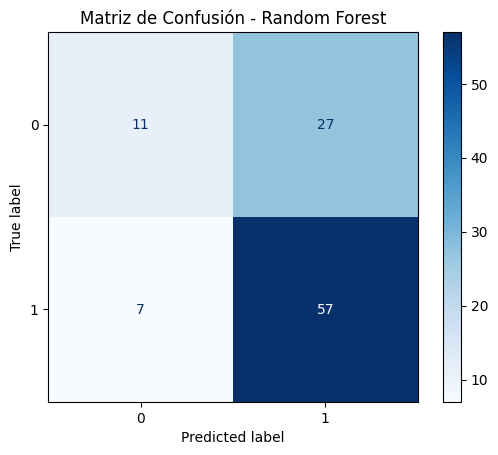


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.61      0.29      0.39        38
           1       0.68      0.89      0.77        64

    accuracy                           0.67       102
   macro avg       0.64      0.59      0.58       102
weighted avg       0.65      0.67      0.63       102


--- Evaluación del modelo: XGBoost ---
Accuracy: 0.6078
Precision: 0.6875
Recall: 0.6875
F1-Score: 0.6875
ROC-AUC: 0.6139

Matriz de Confusión:


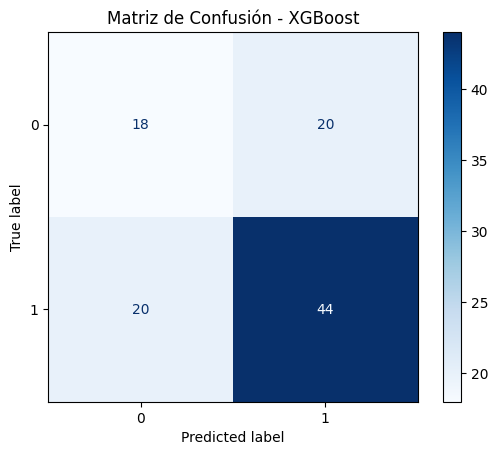


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.47      0.47      0.47        38
           1       0.69      0.69      0.69        64

    accuracy                           0.61       102
   macro avg       0.58      0.58      0.58       102
weighted avg       0.61      0.61      0.61       102



,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,0.666667,0.678571,0.890625,0.77027,0.660979
XGBoost,0.607843,0.687500,0.687500,0.68750,0.613898


In [30]:
results = {}

for name, model in models.items():
    print(f"\n--- Evaluación del modelo: {name} ---")
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Probabilidades de la clase positiva

    # Métricas de evaluación
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    print("\nMatriz de Confusión:")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Matriz de Confusión - {name}')
    plt.show()

    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

# Comparación final de ROC-AUC
df_results = pd.DataFrame(results).T
display(df_results.sort_values(by='ROC-AUC', ascending=False))

#### Importancia de Variables del Mejor Modelo


El modelo con mejor ROC-AUC es: Random Forest (ROC-AUC: 0.6610)

Top 15 variables más importantes para Random Forest:


,feature,importance
6,hdlc,0.092502
5,tg,0.091994
8,CINTURA_CM,0.090499
9,RATIO_CINTURA_CADERA,0.090250
7,ldlc,0.088436
2,IMC,0.085640
4,chol,0.082725
3,glu,0.079187
10,pulse,0.078071
1,agey,0.060868


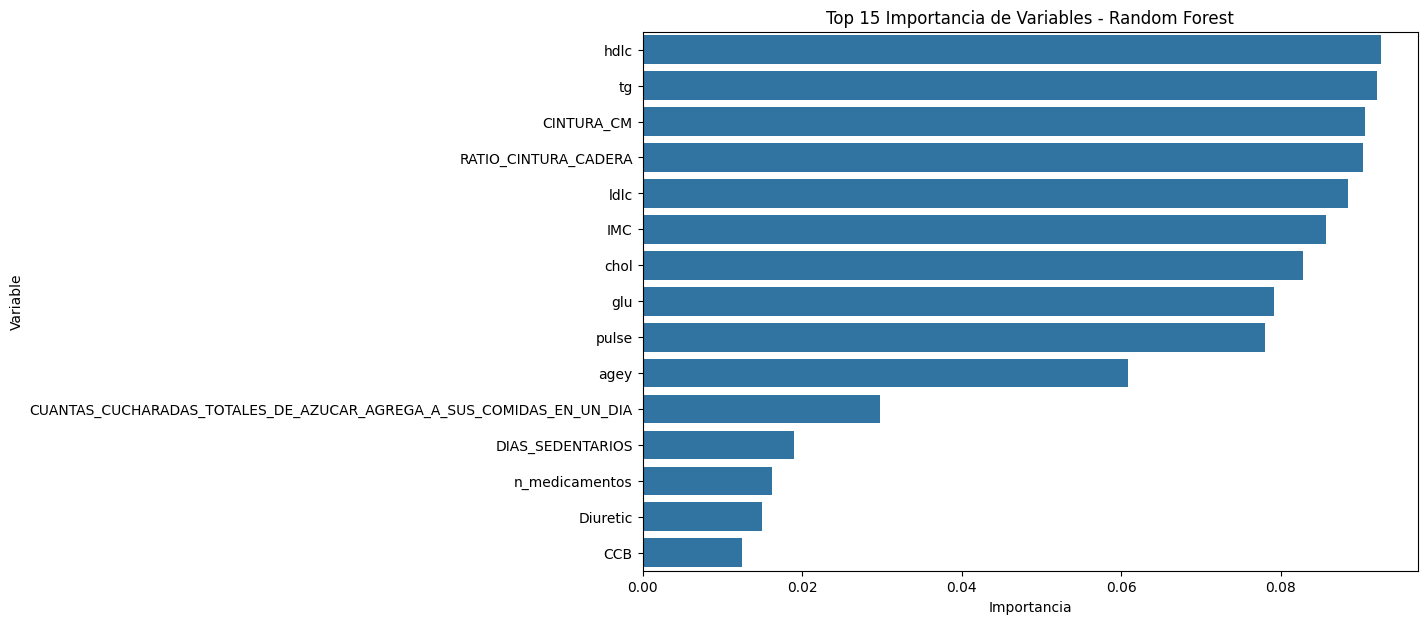

In [31]:
# 6. Muestra qué modelo tuvo mejor ROC-AUC
best_model_name = df_results['ROC-AUC'].idxmax()
best_model = models[best_model_name]

print(f"\nEl modelo con mejor ROC-AUC es: {best_model_name} (ROC-AUC: {df_results['ROC-AUC'].max():.4f})")

# 5. Importancia de variables del mejor modelo
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None

if importances is not None:
    feature_importance_df = pd.DataFrame({'feature': features, 'importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

    print(f"\nTop 15 variables más importantes para {best_model_name}:")
    display(feature_importance_df.head(15))

    plt.figure(figsize=(10, 7))
    sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15))
    plt.title(f'Top 15 Importancia de Variables - {best_model_name}')
    plt.xlabel('Importancia')
    plt.ylabel('Variable')
    plt.show()
else:
    print("No se pudo extraer la importancia de las variables para el mejor modelo.")

### PARTE A — Calibración del modelo

In [32]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Random Forest entrenado anteriormente (rf_model)
#    rf_model está disponible del paso anterior.

# 2. Aplica calibración isotónica con CalibratedClassifierCV
print("\n--- Calibrando Random Forest con CalibratedClassifierCV ---")
calibrated_rf = CalibratedClassifierCV(
    rf_model,  # el Random Forest ya entrenado
    method='isotonic',
    cv=5
)
calibrated_rf.fit(X_train, y_train)
print("Random Forest calibrado.")


--- Calibrando Random Forest con CalibratedClassifierCV ---
Random Forest calibrado.



ROC-AUC del RF original: 0.6610
ROC-AUC del RF calibrado: 0.6466


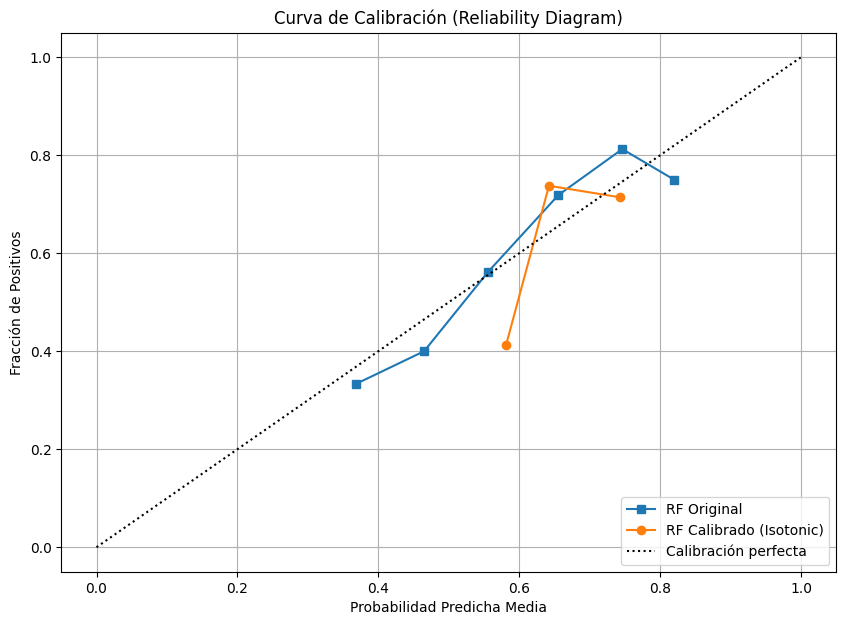

Curva de calibración guardada como calibration_curve.png

Brier Score del RF original: 0.2166
Brier Score del RF calibrado: 0.2268
(Menor es mejor, 0 es perfecto, 0.25 es azar)


In [33]:
# 3. Compara el modelo original vs calibrado

# ROC-AUC de ambos en test set
y_proba_rf_original = rf_model.predict_proba(X_test)[:, 1]
y_proba_rf_calibrated = calibrated_rf.predict_proba(X_test)[:, 1]

roc_auc_rf_original = roc_auc_score(y_test, y_proba_rf_original)
roc_auc_rf_calibrated = roc_auc_score(y_test, y_proba_rf_calibrated)

print(f"\nROC-AUC del RF original: {roc_auc_rf_original:.4f}")
print(f"ROC-AUC del RF calibrado: {roc_auc_rf_calibrated:.4f}")

# Curva de calibración (reliability diagram)
plt.figure(figsize=(10, 7))

fraction_of_positives_orig, mean_predicted_value_orig = calibration_curve(y_test, y_proba_rf_original, n_bins=10)
fraction_of_positives_cal, mean_predicted_value_cal = calibration_curve(y_test, y_proba_rf_calibrated, n_bins=10)

plt.plot(mean_predicted_value_orig, fraction_of_positives_orig, "s-", label="RF Original")
plt.plot(mean_predicted_value_cal, fraction_of_positives_cal, "o-", label="RF Calibrado (Isotonic)")
plt.plot([0, 1], [0, 1], "k:", label="Calibración perfecta")

plt.title('Curva de Calibración (Reliability Diagram)')
plt.xlabel('Probabilidad Predicha Media')
plt.ylabel('Fracción de Positivos')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig('calibration_curve.png')
plt.show()

print("Curva de calibración guardada como calibration_curve.png")

# 4. Reporta el Brier Score de ambos modelos
brier_rf_original = brier_score_loss(y_test, y_proba_rf_original)
brier_rf_calibrated = brier_score_loss(y_test, y_proba_rf_calibrated)

print(f"\nBrier Score del RF original: {brier_rf_original:.4f}")
print(f"Brier Score del RF calibrado: {brier_rf_calibrated:.4f}")
print("(Menor es mejor, 0 es perfecto, 0.25 es azar)")

### PARTE B — Construcción del score

In [34]:
# 1. Recalcula prob_calibrada usando el RF original
prob_rf = rf_model.predict_proba(X)[:, 1]
riesgo_score = (1 - prob_rf) * 100

# Añade riesgo_score a df_active_treatment
df_active_treatment['riesgo_score'] = riesgo_score

print("Score de riesgo recalculado con RF original.")

# 2. Redefine los umbrales basados en la distribución real:
print("\n--- Percentiles del riesgo_score ---")
p33 = np.percentile(riesgo_score, 33)
p66 = np.percentile(riesgo_score, 66)
print(f"Percentil 33: {p33:.2f}")
print(f"Percentil 66: {p66:.2f}")

def classify_risk_percentile(score):
    if score <= p33:
        return 'Bajo'
    elif p33 < score <= p66:
        return 'Medio'
    else:
        return 'Alto'

df_active_treatment['riesgo_nivel'] = df_active_treatment['riesgo_score'].apply(classify_risk_percentile)

print("Niveles de riesgo redefinidos usando percentiles.")

Score de riesgo recalculado con RF original.

--- Percentiles del riesgo_score ---
Percentil 33: 15.50
Percentil 66: 47.96
Niveles de riesgo redefinidos usando percentiles.


In [35]:
# 3. Para cada nivel muestra estadísticas
print("\n--- Estadísticas por Nivel de Riesgo (basado en percentiles) ---")

risk_levels_ordered = ['Bajo', 'Medio', 'Alto'] # Ensure order for consistent output

medication_cols = ['ARA2', 'Diuretic', 'BB']

for nivel in risk_levels_ordered:
    subset_df = df_active_treatment[df_active_treatment['riesgo_nivel'] == nivel]
    n_pacientes = len(subset_df)

    if n_pacientes == 0:
        print(f"\nNivel de Riesgo: {nivel} (0 pacientes)")
        continue

    percent_uncontrolled = (subset_df['presion_controlada'].value_counts(normalize=True).get(0, 0) * 100)

    print(f"\nNivel de Riesgo: {nivel} ({n_pacientes} pacientes)")
    print(f"  % real con presion_controlada == 0: {percent_uncontrolled:.2f}%")
    print(f"  SBP media: {subset_df['SBP'].mean():.2f}")
    print(f"  DBP media: {subset_df['DBP'].mean():.2f}")
    print(f"  IMC media: {subset_df['IMC'].mean():.2f}")
    print(f"  tg media: {subset_df['tg'].mean():.2f}")
    print(f"  hdlc media: {subset_df['hdlc'].mean():.2f}")
    print(f"  n_medicamentos media: {subset_df['n_medicamentos'].mean():.2f}")
    print(f"  % PADECIMIENTO_DIABETES: {(subset_df['PADECIMIENTO_DIABETES'].mean() * 100):.2f}%")
    for med_col in medication_cols:
        print(f"  % {med_col}: {(subset_df[med_col].mean() * 100):.2f}%")


--- Estadísticas por Nivel de Riesgo (basado en percentiles) ---

Nivel de Riesgo: Bajo (170 pacientes)
  % real con presion_controlada == 0: 0.00%
  SBP media: 121.81
  DBP media: 70.68
  IMC media: 28.10
  tg media: 162.94
  hdlc media: 52.44
  n_medicamentos media: 1.51
  % PADECIMIENTO_DIABETES: 20.00%
  % ARA2: 57.06%
  % Diuretic: 27.06%
  % BB: 22.35%

Nivel de Riesgo: Medio (164 pacientes)
  % real con presion_controlada == 0: 14.63%
  SBP media: 127.75
  DBP media: 73.57
  IMC media: 28.51
  tg media: 175.98
  hdlc media: 49.77
  n_medicamentos media: 1.41
  % PADECIMIENTO_DIABETES: 24.39%
  % ARA2: 51.22%
  % Diuretic: 21.34%
  % BB: 21.34%

Nivel de Riesgo: Alto (173 pacientes)
  % real con presion_controlada == 0: 94.80%
  SBP media: 149.39
  DBP media: 85.01
  IMC media: 29.16
  tg media: 181.61
  hdlc media: 47.18
  n_medicamentos media: 1.42
  % PADECIMIENTO_DIABETES: 22.54%
  % ARA2: 57.23%
  % Diuretic: 17.34%
  % BB: 17.34%


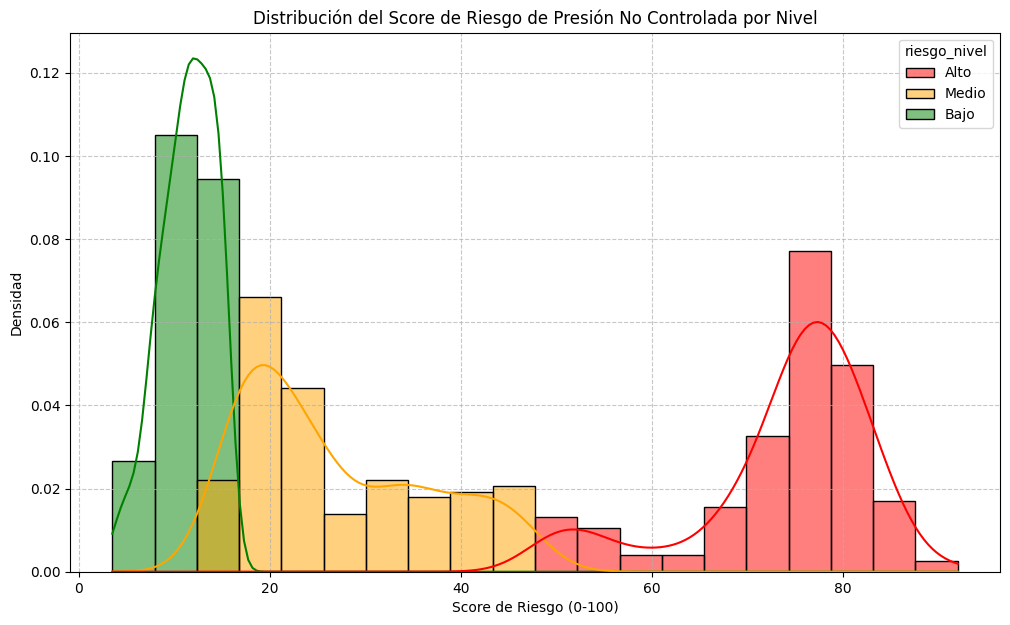

Distribución del score de riesgo guardada como score_distribution.png


In [36]:
# 9. Muestra la distribución del riesgo_score con un histograma coloreado por nivel
plt.figure(figsize=(12, 7))
sns.histplot(
    data=df_active_treatment,
    x='riesgo_score',
    hue='riesgo_nivel',
    palette={'Bajo': 'green', 'Medio': 'orange', 'Alto': 'red'},
    bins=20,
    kde=True,
    stat='density',
    common_norm=False
)
plt.title('Distribución del Score de Riesgo de Presión No Controlada por Nivel')
plt.xlabel('Score de Riesgo (0-100)')
plt.ylabel('Densidad')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('score_distribution.png')
plt.show()

print("Distribución del score de riesgo guardada como score_distribution.png")

### PARTE A — Estratificación por perfil metabólico

#### 1. Define dos grupos en `df_active_treatment`

In [37]:
import numpy as np

# Asegurarse de que df_active_treatment esté disponible
if 'df_active_treatment' not in locals():
    raise ValueError("df_active_treatment no está definido. Ejecute las celdas anteriores.")

# Definir los grupos
# perfil_comprometido: IMC >= 27 OR tg >= 150 OR hdlc < 40
# perfil_saludable: todos los demás

# Para un manejo más robusto de condiciones booleanas con NaNs, usamos .fillna(False) o .copy() para evitar SettingWithCopyWarning
df_active_treatment_copy = df_active_treatment.copy()

df_active_treatment_copy['perfil_comprometido'] = (
    (df_active_treatment_copy['IMC'] >= 27) |
    (df_active_treatment_copy['tg'] >= 150) |
    (df_active_treatment_copy['hdlc'] < 40)
)

# Crear los sub-dataframes para cada perfil
perfil_comprometido_df = df_active_treatment_copy[df_active_treatment_copy['perfil_comprometido'] == True]
perfil_saludable_df = df_active_treatment_copy[df_active_treatment_copy['perfil_comprometido'] == False]

print(f"Pacientes en perfil_comprometido: {len(perfil_comprometido_df)}")
print(f"Pacientes en perfil_saludable: {len(perfil_saludable_df)}")

Pacientes en perfil_comprometido: 426
Pacientes en perfil_saludable: 81


#### 2. Entrena un Random Forest para cada grupo por separado


--- Entrenamiento y Evaluación para perfil_comprometido ---
ROC-AUC en test set para perfil_comprometido: 0.5975

Top 10 variables más importantes para perfil_comprometido:


,feature,importance
9,RATIO_CINTURA_CADERA,0.098043
6,hdlc,0.093149
5,tg,0.090809
8,CINTURA_CM,0.086689
2,IMC,0.085600
4,chol,0.080353
10,pulse,0.078250
3,glu,0.077120
7,ldlc,0.071273
1,agey,0.067703


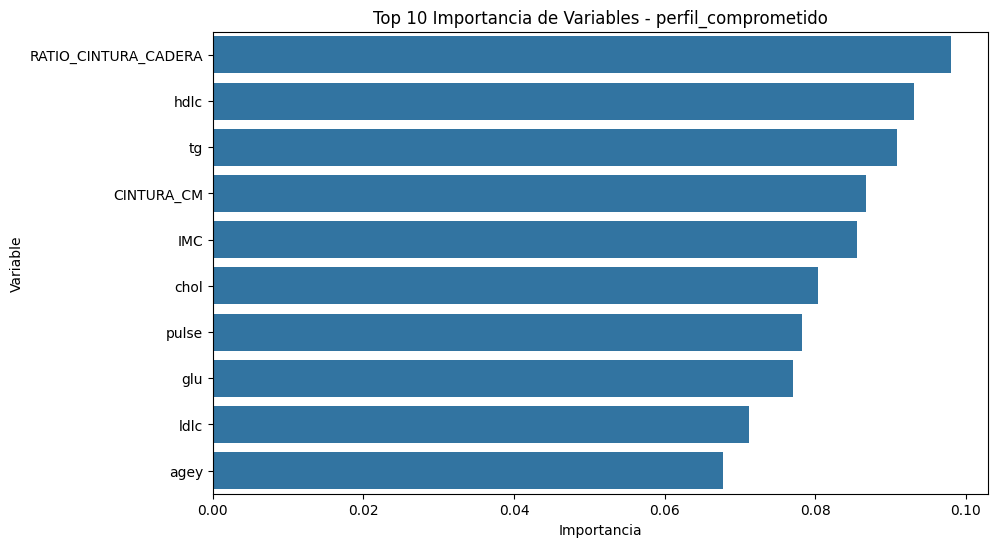


--- Entrenamiento y Evaluación para perfil_saludable ---
ROC-AUC en test set para perfil_saludable: 0.4167

Top 10 variables más importantes para perfil_saludable:


,feature,importance
2,IMC,0.105015
7,ldlc,0.098982
1,agey,0.086791
10,pulse,0.078655
4,chol,0.075755
5,tg,0.074293
9,RATIO_CINTURA_CADERA,0.074190
6,hdlc,0.072180
8,CINTURA_CM,0.069759
3,glu,0.066131


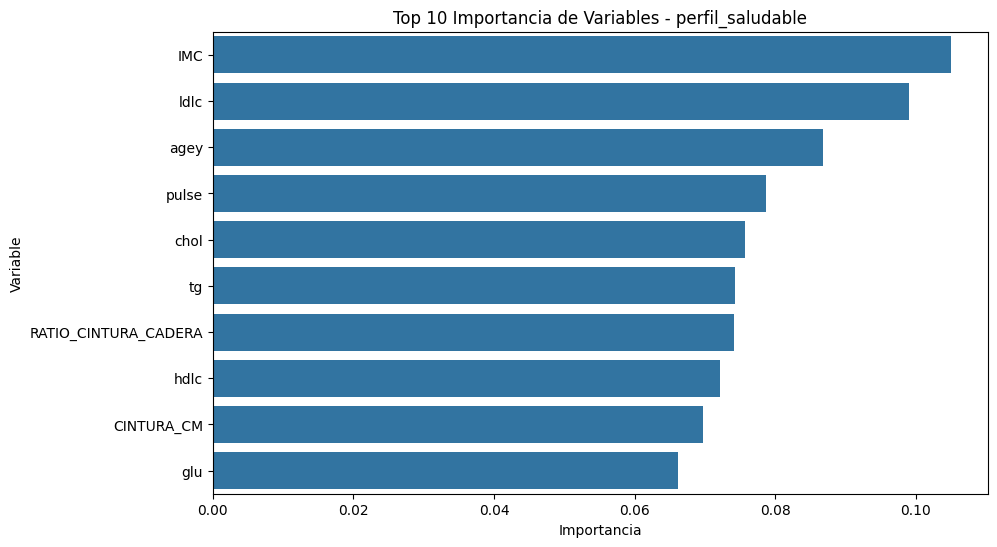

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def train_and_evaluate_rf(data_df, group_name, features, target):
    print(f"\n--- Entrenamiento y Evaluación para {group_name} ---")

    if len(data_df) == 0:
        print(f"No hay pacientes en el grupo '{group_name}'. Saltando entrenamiento.")
        return

    X_group = data_df[features].copy()
    y_group = data_df[target].copy()

    # Eliminar NaNs que puedan surgir en subgrupos, aunque ya deberían estar limpios
    initial_rows_X_group = X_group.shape[0]
    X_group.dropna(inplace=True)
    y_group = y_group.loc[X_group.index]
    if X_group.shape[0] < initial_rows_X_group:
        print(f"Advertencia: Se eliminaron {initial_rows_X_group - X_group.shape[0]} filas con NaNs para el grupo {group_name}.")

    if len(X_group) == 0 or len(y_group.unique()) < 2:
        print(f"No hay suficientes datos o clases para estratificar y entrenar en '{group_name}'. Saltando entrenamiento.")
        return

    X_train_group, X_test_group, y_train_group, y_test_group = train_test_split(
        X_group, y_group, test_size=0.2, random_state=42, stratify=y_group
    )

    rf_group_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf_group_model.fit(X_train_group, y_train_group)

    y_proba_group = rf_group_model.predict_proba(X_test_group)[:, 1]
    roc_auc_group = roc_auc_score(y_test_group, y_proba_group)

    print(f"ROC-AUC en test set para {group_name}: {roc_auc_group:.4f}")

    # Top 10 variables más importantes
    if hasattr(rf_group_model, 'feature_importances_'):
        feature_importance_df_group = pd.DataFrame({'feature': features, 'importance': rf_group_model.feature_importances_})
        feature_importance_df_group = feature_importance_df_group.sort_values(by='importance', ascending=False)

        print(f"\nTop 10 variables más importantes para {group_name}:")
        display(feature_importance_df_group.head(10))

        plt.figure(figsize=(10, 6))
        sns.barplot(x='importance', y='feature', data=feature_importance_df_group.head(10))
        plt.title(f'Top 10 Importancia de Variables - {group_name}')
        plt.xlabel('Importancia')
        plt.ylabel('Variable')
        plt.show()
    else:
        print(f"No se pudo extraer la importancia de las variables para el modelo {group_name}.")

# Asegurarse de que 'features' y 'target' estén definidos
if 'features' not in locals() or 'target' not in locals():
    raise ValueError("Las variables 'features' y 'target' no están definidas. Ejecute las celdas anteriores.")

# Entrenar y evaluar para perfil_comprometido
train_and_evaluate_rf(perfil_comprometido_df, 'perfil_comprometido', features, target)

# Entrenar y evaluar para perfil_saludable
train_and_evaluate_rf(perfil_saludable_df, 'perfil_saludable', features, target)

### PARTE B — Análisis counterfactual simple

#### 3. Toma los 188 pacientes con `tratamiento_inefectivo == 1` de `df_clean`

In [39]:
if 'df_clean' not in locals() or 'best_model' not in locals() or 'features' not in locals():
    raise ValueError("Asegúrese de que df_clean, best_model y features estén definidos en celdas anteriores.")

# Filtrar pacientes con tratamiento inefectivo
ineffective_patients_df = df_clean[df_clean['tratamiento_inefectivo'] == 1].copy()

print(f"Número de pacientes con tratamiento inefectivo: {len(ineffective_patients_df)}")

# Copia de las características para la simulación
X_counterfactual_base = ineffective_patients_df[features].copy()

# Asegurarse de que X_counterfactual_base no tenga NaNs para la predicción
initial_rows_X_counterfactual = X_counterfactual_base.shape[0]
X_counterfactual_base.dropna(inplace=True)
if X_counterfactual_base.shape[0] < initial_rows_X_counterfactual:
    print(f"Advertencia: Se eliminaron {initial_rows_X_counterfactual - X_counterfactual_base.shape[0]} filas con NaNs del conjunto de pacientes inefectivos para el análisis contrafactual.")

# Obtener las predicciones base (antes de cualquier cambio) para estos pacientes
y_pred_base = best_model.predict(X_counterfactual_base)

print(f"Predicciones base: {np.sum(y_pred_base == 1)} pacientes con presión controlada (según modelo) antes de cambios.")

Número de pacientes con tratamiento inefectivo: 188
Predicciones base: 27 pacientes con presión controlada (según modelo) antes de cambios.


#### 4. Simula cambios individuales y predice

In [40]:
results_counterfactual = []

# Función para simular y predecir un escenario
def simulate_scenario(X_base, y_base_pred, feature_to_change, change_value=None, condition_col=None, condition_value=None, action='add'):
    X_scenario = X_base.copy()

    if condition_col is not None:
        # Aplicar el cambio solo si se cumple la condición
        if action == 'add': # Para Diuretic/BB=1 si no lo toman
            mask = (X_scenario[condition_col] == condition_value)
            X_scenario.loc[mask, feature_to_change] = 1
        elif action == 'subtract':
            X_scenario.loc[mask, feature_to_change] = X_scenario[feature_to_change] - change_value
        elif action == 'set': # Para cambios directos (e.g., IMC)
            X_scenario[feature_to_change] = change_value
    else:
        # Aplicar el cambio directamente
        if action == 'subtract': # IMC, tg
            X_scenario[feature_to_change] = X_scenario[feature_to_change] - change_value
        elif action == 'add': # hdlc
            X_scenario[feature_to_change] = X_scenario[feature_to_change] + change_value

    y_pred_scenario = best_model.predict(X_scenario)

    # Contar cuántos pacientes pasarían de NO controlada (0) a controlada (1)
    # y_base_pred es la predicción de la presión para el estado actual de los pacientes
    # y_pred_scenario es la predicción de la presión para el estado simulado de los pacientes
    # Queremos aquellos que originalmente eran 0 (no controlada) y ahora son 1 (controlada)
    improved_patients_count = np.sum((y_base_pred == 0) & (y_pred_scenario == 1))
    total_ineffective_base = np.sum(y_base_pred == 0)

    percentage_improved = (improved_patients_count / total_ineffective_base * 100) if total_ineffective_base > 0 else 0

    return improved_patients_count, percentage_improved

# Re-calcular y_pred_base para asegurar que usamos el X_counterfactual_base sin NaNs
y_pred_base = best_model.predict(X_counterfactual_base)

# Escenario 1: reducir IMC en 2 unidades
count1, perc1 = simulate_scenario(X_counterfactual_base, y_pred_base, 'IMC', change_value=2, action='subtract')
results_counterfactual.append({
    'Escenario': 'Reducir IMC en 2 unidades',
    'Pacientes que cambian a controlada': count1,
    '%': perc1
})

# Escenario 2: reducir tg en 20 mg/dL
count2, perc2 = simulate_scenario(X_counterfactual_base, y_pred_base, 'tg', change_value=20, action='subtract')
results_counterfactual.append({
    'Escenario': 'Reducir tg en 20 mg/dL',
    'Pacientes que cambian a controlada': count2,
    '%': perc2
})

# Escenario 3: aumentar hdlc en 5 mg/dL
count3, perc3 = simulate_scenario(X_counterfactual_base, y_pred_base, 'hdlc', change_value=5, action='add')
results_counterfactual.append({
    'Escenario': 'Aumentar hdlc en 5 mg/dL',
    'Pacientes que cambian a controlada': count3,
    '%': perc3
})

# Escenario 4: cambiar a Diuretic=1 (si no lo toma)
count4, perc4 = simulate_scenario(X_counterfactual_base, y_pred_base, 'Diuretic', condition_col='Diuretic', condition_value=0, action='add')
results_counterfactual.append({
    'Escenario': 'Cambiar a Diuretic=1 (si no lo toma)',
    'Pacientes que cambian a controlada': count4,
    '%': perc4
})

# Escenario 5: cambiar a BB=1 (si no lo toma)
count5, perc5 = simulate_scenario(X_counterfactual_base, y_pred_base, 'BB', condition_col='BB', condition_value=0, action='add')
results_counterfactual.append({
    'Escenario': 'Cambiar a BB=1 (si no lo toma)',
    'Pacientes que cambian a controlada': count5,
    '%': perc5
})

# Convertir resultados a DataFrame
df_counterfactual_results = pd.DataFrame(results_counterfactual)

print("\n--- Resultados del Análisis Contrafactual ---")
display(df_counterfactual_results.round(2))


--- Resultados del Análisis Contrafactual ---


,Escenario,Pacientes que cambian a controlada,%
0,Reducir IMC en 2 unidades,4,2.48
1,Reducir tg en 20 mg/dL,3,1.86
2,Aumentar hdlc en 5 mg/dL,6,3.73
3,Cambiar a Diuretic=1 (si no lo toma),5,3.11
4,Cambiar a BB=1 (si no lo toma),3,1.86


In [41]:
# 1. Identificar pacientes de alta prioridad
high_priority_patients = df_active_treatment[
    (df_active_treatment['riesgo_nivel'] == 'Alto') &
    (df_active_treatment['tratamiento_inefectivo'] == 1)
].copy()

print(f"Número de pacientes de alta prioridad (riesgo Alto y tratamiento inefectivo): {len(high_priority_patients)}")
print("Primeros 5 pacientes de alta prioridad:")
display(high_priority_patients.head())

Número de pacientes de alta prioridad (riesgo Alto y tratamiento inefectivo): 164
Primeros 5 pacientes de alta prioridad:


,Paciente_ID,Sx,agey,weightKg,heightm,SBP,DBP,pulse,glu,HIPOGLUCEMIANTE,...,CINTURA_CM,CADERA_CM,RATIO_CINTURA_CADERA,DIAS_SEDENTARIOS,DIAS_CAMINATAS,HORAS_CAMINANDO,presion_controlada,tratamiento_inefectivo,riesgo_score,riesgo_nivel
0,2018-2-2018,1.0,68.0,77.10,1.64,141.0,85.0,66.0,132.0,1.0,...,95.100000,98.033333,0.970078,6.0,6.0,3.0,0,1,81.5,Alto
8,2018-23,1.0,68.0,86.53,1.71,187.0,101.0,75.0,147.0,0.0,...,107.200000,102.733333,1.043478,1.5,3.5,1.5,0,1,58.0,Alto
14,2018-49,1.0,68.0,62.87,1.60,169.0,91.0,91.0,145.0,1.0,...,91.000000,86.000000,1.058140,0.0,1.5,1.5,0,1,82.5,Alto
32,2018-128,2.0,66.0,71.50,1.49,147.0,70.0,70.0,112.0,0.0,...,104.533333,103.666667,1.008360,6.0,3.5,0.5,0,1,76.5,Alto
33,2018-134,2.0,80.0,58.30,1.42,146.0,86.0,70.0,92.0,0.0,...,89.366667,110.933333,0.805589,3.5,3.5,1.5,0,1,71.0,Alto


#### 2. Instalar y configurar DiCE

In [42]:
# Instalar dice_ml si no está instalado
!pip install dice-ml

import dice_ml
import pandas as pd

# Define the features that DiCE should consider as categorical and continuous
categorical_features = [
    'Sx', 'n_medicamentos', 'ACEi', 'ARA2', 'CCB', 'Diuretic', 'BB',
    'PADECIMIENTO_DIABETES', 'HIPOGLUCEMIANTE',
    'AGREGA_SAL_A_SUS_ALIMENTOS_ANTES_DE_PROBARLOS',
    'DIAS_SEDENTARIOS', # Mover a categóricas
    'CUANTAS_CUCHARADAS_TOTALES_DE_AZUCAR_AGREGA_A_SUS_COMIDAS_EN_UN_DIA' # Mover a categóricas
]
continuous_features = [
    'agey', 'IMC', 'glu', 'chol', 'tg', 'hdlc', 'ldlc', 'CINTURA_CM',
    'RATIO_CINTURA_CADERA', 'pulse'
]

# Ensure `df_active_treatment_for_dice` is a mutable copy to avoid SettingWithCopyWarning
df_active_treatment_for_dice = df_active_treatment[features + [target]].copy()

# Explicitly convert all specified categorical features to string type for DiCE
# This is crucial for DiCE to correctly interpret the categories.
for col in categorical_features:
    if col in df_active_treatment_for_dice.columns:
        # Convert to string, handling NaNs if any (though df_clean should have handled most)
        df_active_treatment_for_dice[col] = df_active_treatment_for_dice[col].astype(str)

# Ensure `azucar_unique` and `dias_sedentarias_unique` are defined and are lists of string representations
# These should now directly come from the string-converted columns
azucar_unique = sorted(df_active_treatment_for_dice['CUANTAS_CUCHARADAS_TOTALES_DE_AZUCAR_AGREGA_A_SUS_COMIDAS_EN_UN_DIA'].dropna().unique().tolist())
dias_sedentarias_unique = sorted(df_active_treatment_for_dice['DIAS_SEDENTARIOS'].dropna().unique().tolist())

# Crear el objeto Data
d = dice_ml.Data(
    dataframe=df_active_treatment_for_dice,
    continuous_features=continuous_features,
    categorical_features=categorical_features,
    outcome_name=target
)

# Crear el modelo DiCE
m = dice_ml.Model(model=rf_model, backend='sklearn')

# Crear el explicador DiCE
exp = dice_ml.Dice(d, m, method='random') # Usando el método 'random' como base

print("DiCE configurado exitosamente.")

ModuleNotFoundError: No module named 'dice_ml'

In [ ]:
# 3. Generar 3 ejemplos contrafactuales para los primeros 5 pacientes de alta prioridad
print("\n--- Generando ejemplos contrafactuales para pacientes de alta prioridad ---")

# Seleccionar los primeros 5 pacientes de alta prioridad
query_instances = high_priority_patients[features].head(5)

# Generar contrafactuales
dice_exp = exp.generate_counterfactuals(
    query_instances,
    total_CFs=3,
    desired_class="opposite", # Deseamos cambiar la clase (de 0 a 1)
    features_to_vary=continuous_features + ['DIAS_SEDENTARIOS', 'ACEi', 'ARA2', 'CCB', 'Diuretic', 'BB', 'CUANTAS_CUCHARADAS_TOTALES_DE_AZUCAR_AGREGA_A_SUS_COMIDAS_EN_UN_DIA'], # Permitir variar más características relevantes
    permitted_range={ # Definir rangos permisibles para cambios realistas
        'IMC': [18.5, 40],
        'tg': [50, 400],
        'hdlc': [20, 100],
        'CUANTAS_CUCHARADAS_TOTALES_DE_AZUCAR_AGREGA_A_SUS_COMIDAS_EN_UN_DIA': azucar_unique, # Usar valores únicos
        'DIAS_SEDENTARIOS': dias_sedentarias_unique # Usar valores únicos
    }
)

print("Ejemplos contrafactuales generados.")

# 4. Mostrar los contrafactuales generados
print("\n--- Visualización de los contrafactuales ---")
dice_exp.visualize_as_dataframe(show_only_changes=True)

In [ ]:
import dice_ml

# 1. Reinicializa DiCE con method='kdtree'
exp_kdtree = dice_ml.Dice(d, m, method='kdtree')

print("DiCE explainer con método 'kdtree' configurado exitosamente.")

# 2. Generar 3 ejemplos contrafactuales para los primeros 5 pacientes de alta prioridad
print("\n--- Generando ejemplos contrafactuales para pacientes de alta prioridad con kdtree ---")

# Seleccionar los primeros 5 pacientes de alta prioridad
query_instances = high_priority_patients[features].head(5)

# Expand features_to_vary to include all features from the model
features_to_vary = features # Use the full list of features

# Remove permitted_range entirely for this diagnostic step
dice_exp_kdtree = exp_kdtree.generate_counterfactuals(
    query_instances,
    total_CFs=10, # Increased total_CFs to 10
    desired_class="opposite", # Deseamos cambiar la clase (de 0 a 1)
    features_to_vary=features_to_vary
)

print("Ejemplos contrafactuales generados con kdtree.")

# Mostrar los contrafactuales generados
print("\n--- Visualización de los contrafactuales (show_only_changes=True) ---")
dice_exp_kdtree.visualize_as_dataframe(show_only_changes=True)

In [ ]:
import pandas as pd
import numpy as np

# Define medication_binary_cols here to be available for get_numerical_value
medication_binary_cols = ['ACEi', 'ARA2', 'CCB', 'Diuretic', 'BB']

# Helper function to ensure consistent numerical representation for magnitude/direction comparison
# This is useful because original_instance might have floats, but CFs for 'CUANTAS...' and 'DIAS...' are strings
def get_numerical_value(val, feature_name, medication_binary_cols):
    # If the value is 'nan' string (from astype(str)) or actual pd.NA/np.nan, treat as NaN
    if pd.isna(val) or str(val).lower() == 'nan':
        return np.nan

    if feature_name in ['CUANTAS_CUCHARADAS_TOTALES_DE_AZUCAR_AGREGA_A_SUS_COMIDAS_EN_UN_DIA', 'DIAS_SEDENTARIOS'] or feature_name in medication_binary_cols:
        try:
            return float(val)
        except (ValueError, TypeError):
            return np.nan
    return val # For other purely numerical features, return as is

# 3. Validar CFs y construir tabla resumen
summary_data = []

# Ensure `azucar_unique` and `dias_sedentarias_unique` are defined from previous steps
# Derive them from the preprocessed data that DiCE will use
azucar_unique = sorted(df_active_treatment_for_dice['CUANTAS_CUCHARADAS_TOTALES_DE_AZUCAR_AGREGA_A_SUS_COMIDAS_EN_UN_DIA'].dropna().unique().tolist())
dias_sedentarias_unique = sorted(df_active_treatment_for_dice['DIAS_SEDENTARIOS'].dropna().unique().tolist())

# Redefine permitted_range_dict for validation (using the same logic as for CF generation)
permitted_range_dict = {
    'IMC': [18.5, 40],
    'tg': [50, 400],
    'hdlc': [20, 100],
    'CUANTAS_CUCHARADAS_TOTALES_DE_AZUCAR_AGREGA_A_SUS_COMIDAS_EN_UN_DIA': azucar_unique, # List of strings
    'DIAS_SEDENTARIOS': dias_sedentarias_unique # List of strings
}

# Dynamically add permitted ranges for binary medication columns based on actual unique values (as strings)
for col in medication_binary_cols:
    if col in df_active_treatment_for_dice.columns:
        # Get unique values as strings and remove 'nan' if present
        unique_str_values = [str(x) for x in df_active_treatment_for_dice[col].dropna().unique().tolist()]
        if unique_str_values:
            permitted_range_dict[col] = sorted(unique_str_values)

for i, query_index in enumerate(query_instances.index):
    patient_id = high_priority_patients.loc[query_index, 'Paciente_ID']
    original_instance = query_instances.loc[query_index]

    # Check if dice_exp_kdtree was successfully created and has cf_examples_list
    if 'dice_exp_kdtree' not in locals() or not hasattr(dice_exp_kdtree, 'cf_examples_list') or i >= len(dice_exp_kdtree.cf_examples_list):
        print(f"Advertencia: No se encontraron contrafactuales para el paciente {patient_id}. Saltando.")
        continue

    cfs_df = dice_exp_kdtree.cf_examples_list[i].final_cfs_df

    for cf_idx in range(len(cfs_df)):
        cf_instance = cfs_df.iloc[cf_idx]
        is_valid = True
        invalid_vars = []
        changed_vars_info = []

        for feature in features_to_vary:
            original_value = original_instance[feature]
            cf_value = cf_instance[feature]

            # 1. Validate against permitted_range first
            if feature in permitted_range_dict:
                perm_range = permitted_range_dict[feature]

                if feature in ['CUANTAS_CUCHARADAS_TOTALES_DE_AZUCAR_AGREGA_A_SUS_COMIDAS_EN_UN_DIA', 'DIAS_SEDENTARIOS'] or feature in medication_binary_cols:
                    # For these, CF value is expected to be a string, check if it's in the list of valid strings
                    if str(cf_value) not in perm_range:
                        is_valid = False
                        invalid_vars.append(feature)
                elif isinstance(perm_range[0], (int, float)) and isinstance(perm_range[1], (int, float)): # For purely numerical features (e.g., IMC, tg, hdlc)
                    if not (perm_range[0] <= cf_value <= perm_range[1]):
                        is_valid = False
                        invalid_vars.append(feature)

            # If the value is invalid, we don't proceed to calculate changes for it, so continue to the next feature
            if not is_valid and feature in invalid_vars:
                continue

            # 2. Check if value has changed and calculate direction/magnitud
            # Get numerical versions for comparison of change and magnitude
            original_num_val = get_numerical_value(original_value, feature, medication_binary_cols)
            cf_num_val = get_numerical_value(cf_value, feature, medication_binary_cols)

            has_changed = False
            # Compare original and CF values directly (as strings for categorical, floats for numerical)
            if feature in ['CUANTAS_CUCHARADAS_TOTALES_DE_AZUCAR_AGREGA_A_SUS_COMIDAS_EN_UN_DIA', 'DIAS_SEDENTARIOS'] or feature in medication_binary_cols:
                if str(original_value) != str(cf_value):
                    has_changed = True
            elif isinstance(original_num_val, (int, float)) and isinstance(cf_num_val, (int, float)):
                if pd.isna(original_num_val) != pd.isna(cf_num_val): # Change from NaN to value or vice-versa
                    has_changed = True
                elif not pd.isna(original_num_val) and not pd.isna(cf_num_val) and not np.isclose(original_num_val, cf_num_val, equal_nan=False):
                    has_changed = True
            else: # Fallback for other types or if types mismatch unexpectedly
                if original_value != cf_value:
                    has_changed = True


            if has_changed:
                direction = ''
                magnitude = 0.0

                if feature in medication_binary_cols: # Binary medications, now treated as strings '0' or '1'
                    # Compare original_value and cf_value as strings as they are stored as such in df_active_treatment_for_dice
                    if str(cf_value) == '1' and str(original_value) == '0':
                        direction = 'agrega'
                        magnitude = 1
                    elif str(cf_value) == '0' and str(original_value) == '1':
                        direction = 'quita'
                        magnitude = 1
                else: # Numerical or pseudo-categorical-numerical features (where original_num_val and cf_num_val are floats)
                    if original_num_val < cf_num_val:
                        direction = 'sube'
                    elif original_num_val > cf_num_val:
                        direction = 'baja'

                    magnitude = np.abs(cf_num_val - original_num_val)

                if direction: # Only add if a change was identified and processed
                    changed_vars_info.append({
                        'variable': feature,
                        'direccion': direction,
                        'magnitud': f'{magnitude:.2f} unidades' if feature not in medication_binary_cols else f'{int(magnitude)} unidad'
                    })

        print(f"Paciente {i+1} (ID: {patient_id}), CF {cf_idx+1}: {'VÁLIDO' if is_valid else 'INVÁLIDO - variables fuera de rango: ' + ', '.join(invalid_vars)}")

        if is_valid and changed_vars_info: # Only add to summary if the CF is valid and had changes
            for change in changed_vars_info:
                summary_data.append({
                    'Paciente_ID': patient_id,
                    'Paciente_idx': query_index,
                    'CF_numero': cf_idx + 1,
                    'Variable_que_cambia': change['variable'],
                    'Direccion_cambio': change['direccion'],
                    'Magnitud_cambio': change['magnitud'],
                    'Valor_original': original_instance[change['variable']],
                    'Valor_CF': cfs_df.iloc[cf_idx][change['variable']]
                })

df_recomendaciones = pd.DataFrame(summary_data)

print("\n--- Tabla de Recomendaciones Contrafactuales (solo CFs válidos y con cambios) ---")
display(df_recomendaciones)

In [ ]:
# 4. Exportar tabla a Excel
excel_filename = 'recomendaciones_counterfactuales.xlsx'
df_recomendaciones.to_excel(excel_filename, index=False)

print(f"Tabla de recomendaciones exportada a '{excel_filename}'")